# **Analysis on clinical embeddings**

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
import subprocess

from foundation.clinical import pipeline_clinical

from gbmhackathon.data import MosaicDataset
from gbmhackathon.s3_loader import load_s3, write_s3

### Generate clinical embedding with correct processing

In [2]:
# clinical_data = pipeline_clinical(verbose=True)
# write_s3(clinical_data, 'clinical_emb_V1', 'embedding_V1')

In [3]:
# clinical_data['dataset'].keys()

### Load data

In [4]:
BUCKET_MOSAIC = "ABSTRA_DATASET_03bb30aa_16ed_4b89_913e_fe009db2aabd"
BUCKET_PROJECT = "ABSTRA_PROJECT_STORAGE_BUCKET"

def fetch_path(env_var_name):
    return os.path.expandvars(f"${env_var_name}")

S3_PATH_CLINICAL_EMB = fetch_path(BUCKET_PROJECT) + "embedding_V1/2025-03-30_14-23_clinical_emb_V1.pkl"
S3_PATH_MODALITIES_PER_SAMPLES = fetch_path(BUCKET_MOSAIC) + "Data availibility per modality per sample.csv"
S3_PATH_PROJECT = fetch_path(BUCKET_PROJECT)

In [5]:
clinical_dict = load_s3(S3_PATH_CLINICAL_EMB)

### Retrieve modalities per samples

In [6]:
#modality_per_sample = pd.read_csv(S3_PATH_MODALITIES_PER_SAMPLES)
#modality_per_sample.index = modality_per_sample['Hackathon_ID']
#modality_per_sample = modality_per_sample[[col for col in modality_per_sample.columns if col != 'Hackathon_ID']]
#modality_per_sample

In [7]:
# def get_missing(row):
#     columns = row.index
#     missing = []
#     for i in range(len(row)):
#         if row.iloc[i] == 'No':
#             missing.append(columns[i].split("_")[0])
#     return missing

# missing_mod = modality_per_sample.apply(get_missing, axis=1)

In [8]:
# dico_missing_mod = {idx:missing_mod.loc[idx] for idx in missing_mod.index if len(missing_mod.loc[idx]) != 6}

In [9]:
# dico_missing_mod

In [10]:
#import s3fs
#path = f"{S3_PATH_PROJECT}missing_mod_per_samples.pkl"
#fs = s3fs.S3FileSystem()
#with fs.open(path=path, mode = "wb") as f : 
#    pkl.dump(dico_missing_mod, f)

In [11]:
clinical_dict['dataset'].keys()

dict_keys(['id2row', 'cat_features', 'num_features', 'features', 'targets', 'mca_contributions', 'X', 'Y', 'imputed_Y', 'original_Y'])

In [12]:
clinical_dict['dataset']['features']

['age_at_diagnosis_years',
 'time_interval_sample_harvest_dearchival_years',
 'C0',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9']

### Analysis

In [13]:
id2row = clinical_dict['dataset']['id2row']
X = clinical_dict['dataset']['X']
Y = clinical_dict['dataset']['Y']
features = clinical_dict['dataset']['features']
targets = clinical_dict['dataset']['targets']
per_mod_contributions = clinical_dict['dataset']['mca_contributions']

In [14]:
X_df = pd.DataFrame(X.numpy(), columns=features, index=list(id2row.keys()))
Y_df = pd.DataFrame(Y.numpy(), columns=targets, index=list(id2row.keys()))
dataset = pd.concat([X_df, Y_df], axis=1)

### Correlations

Look at correlations between input features and target variables but also between input features themselves.

<Axes: >

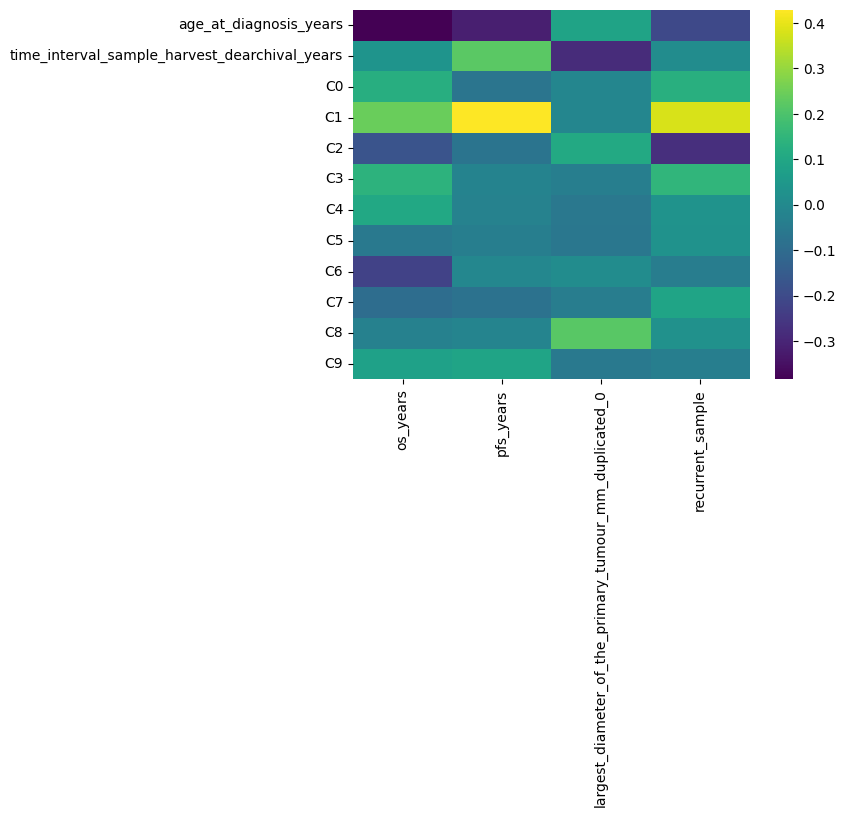

In [15]:
corr = dataset.corr()

sns.heatmap(corr[targets].loc[features], yticklabels=True, cmap='viridis')

Component 2 seems to be quite correlated to progression free years and recurrency. Otherwise, no particular correlation seems to be notable regarding other features with respect to target variables.

Let's look at MCA contributions.

<Axes: ylabel='feature'>

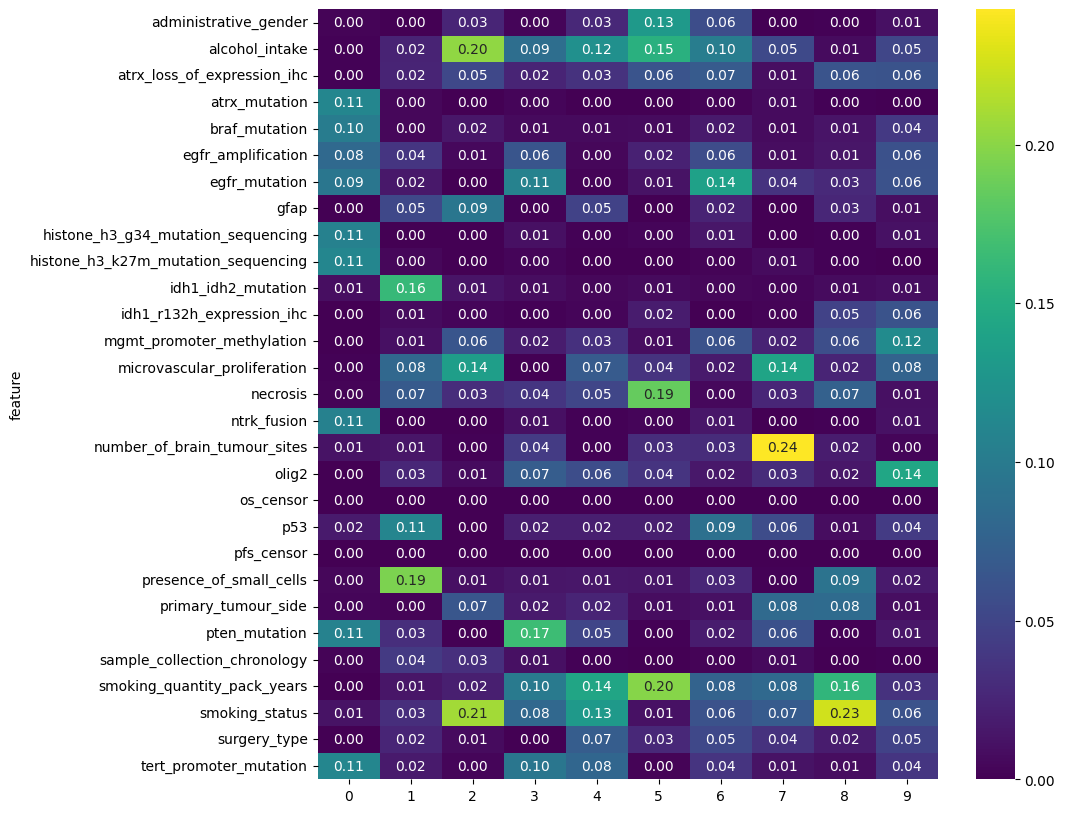

In [16]:
plt.figure(figsize=(10,10))
per_col_contributions = per_mod_contributions.groupby("feature").sum()
sns.heatmap(per_col_contributions, cmap='viridis', annot=True, fmt='.2f', yticklabels=True)

Interestingly, component 1 is mainly contributed by presence_of_small_cells, idh1_idh2_mutation and p53. Let's look more precisely.

<Axes: >

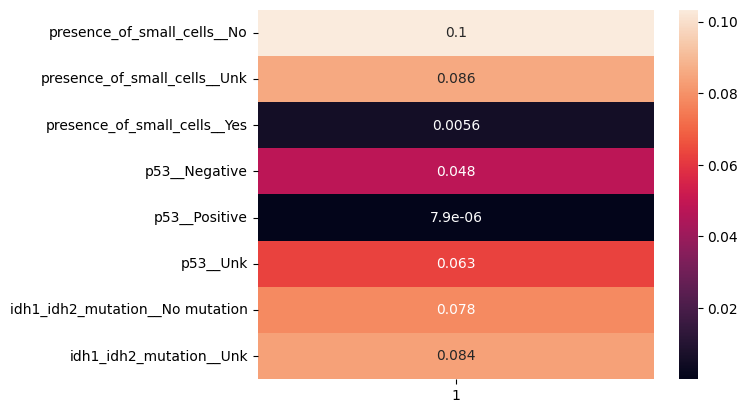

In [17]:
sns.heatmap(per_mod_contributions[per_mod_contributions["feature"].isin(["presence_of_small_cells", "idh1_idh2_mutation", "p53"])][[1]], annot=True)

We can see that the indication that an information is missing is quite important for several features regarding their contribution to component 1. This reveals how the absence of information is an information in itself. When looking at known modalities, the absence of small cells and the absence of idh1/idh2 mutations are the most contributing modalities to this component. Progression free years is thus correlated with these conditions.

<Axes: >

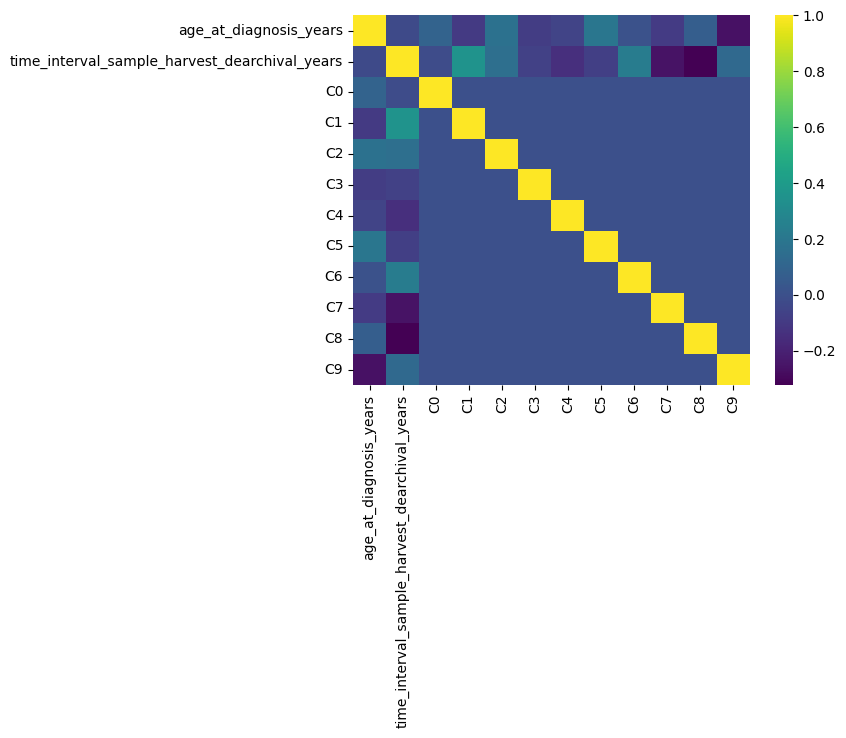

In [18]:
sns.heatmap(corr[features].loc[features], yticklabels=True, cmap='viridis')

As expected MCA components are decorrelated (sanity check). Moreover, both numerical features are not particularly correlated with any other feature. This is nice to have because it means that our feature set will not contain too many redundant information which should be of value when training our model.

### T-SNE

Look at patients using TSNE projection and color by target variables

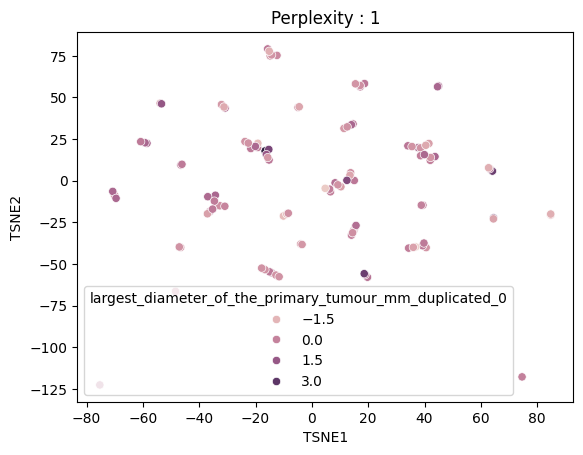

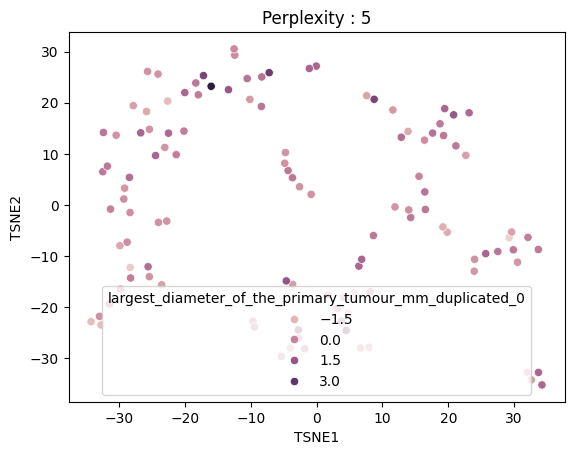

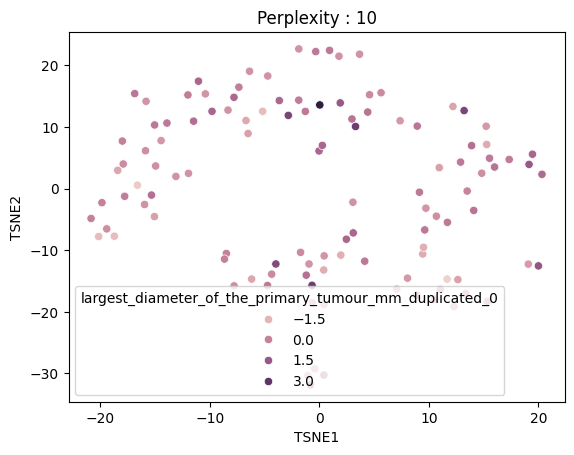

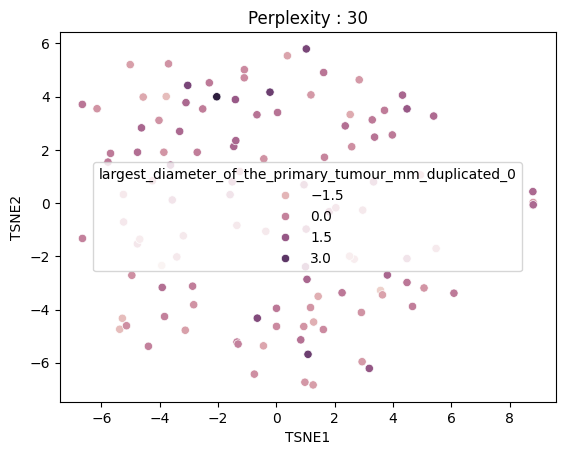

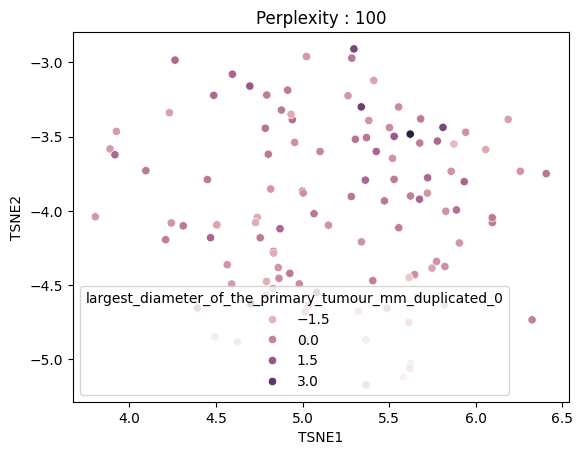

In [19]:
from sklearn.manifold import TSNE

for p in [1, 5, 10, 30, 100]:
    tsne = TSNE(perplexity=p)
    tsne_X = pd.DataFrame(tsne.fit_transform(X_df), columns=['TSNE1', 'TSNE2'], index=X_df.index)

    tsne_df = pd.concat([tsne_X, Y_df], axis=1)
    sns.scatterplot(tsne_df, x='TSNE1', y='TSNE2', hue="largest_diameter_of_the_primary_tumour_mm_duplicated_0")
    plt.title(f"Perplexity : {p}")
    plt.show()

In [20]:
tsne = TSNE(perplexity=5)
tsne_X = pd.DataFrame(tsne.fit_transform(X_df), columns=['TSNE1', 'TSNE2'], index=X_df.index)

tsne_df = pd.concat([tsne_X, Y_df], axis=1)

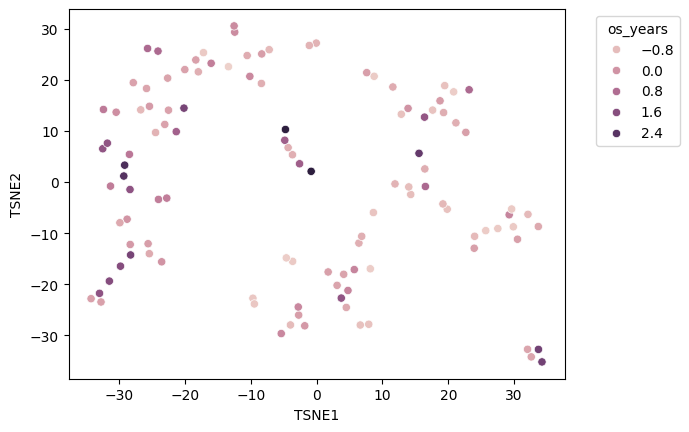

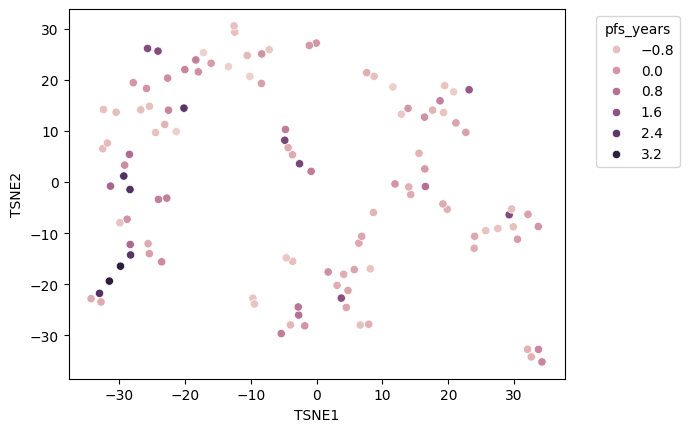

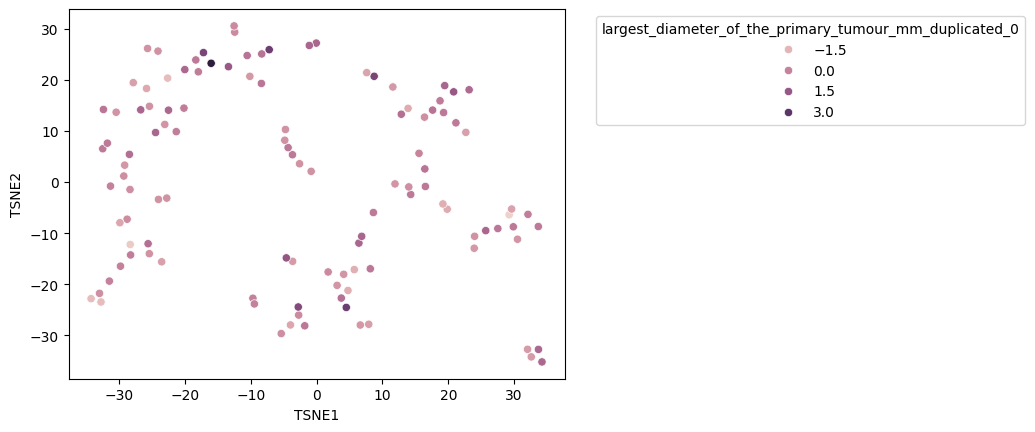

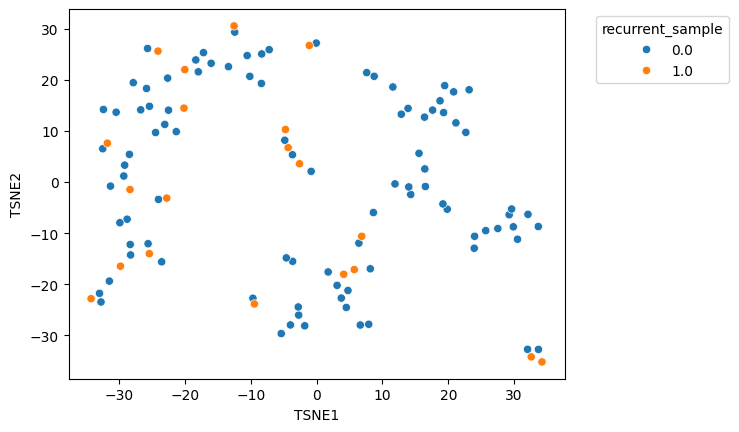

In [21]:
for target in targets:
    sns.scatterplot(tsne_df, x='TSNE1', y='TSNE2', hue=target)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title=target)
    plt.show()

### UMAP

Look at patients using UMAP projection and color by target variables

In [22]:
from umap import UMAP


umap = UMAP()
umap_X = pd.DataFrame(umap.fit_transform(X_df), columns=['UMAP1', 'UMAP2'], index=X_df.index)

umap_df = pd.concat([umap_X, Y_df], axis=1)

/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


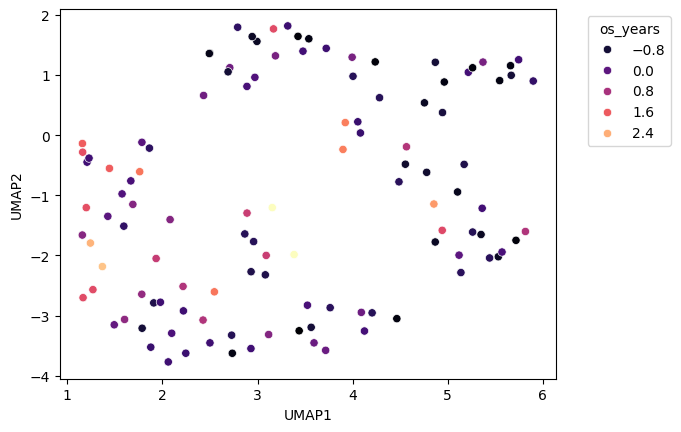

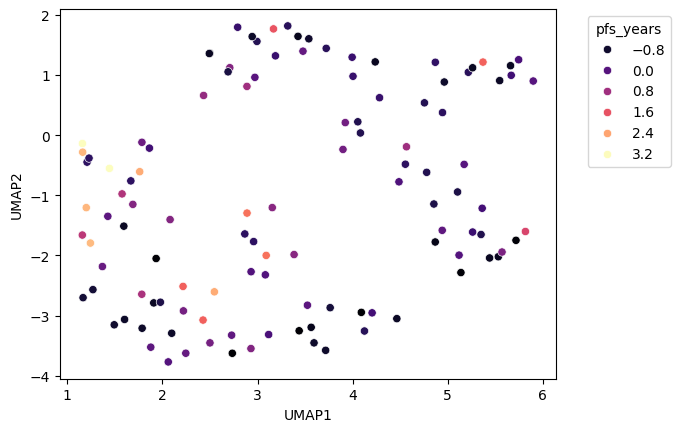

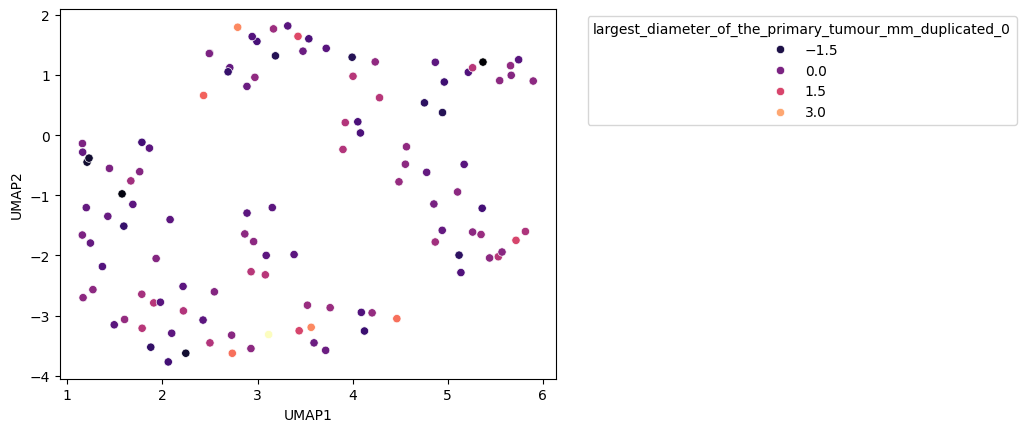

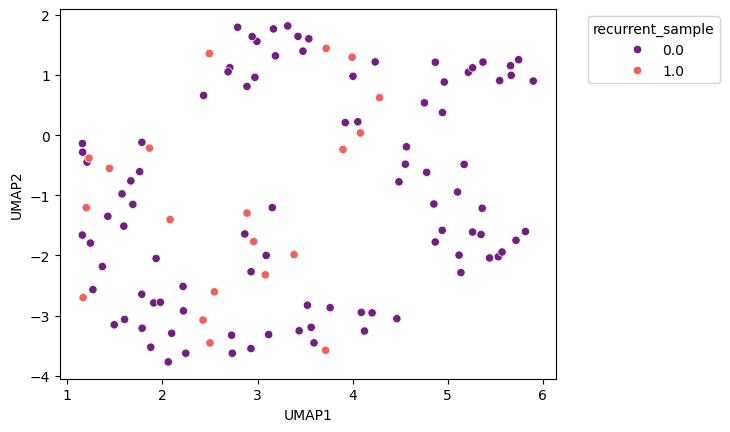

In [23]:
for target in targets:
    sns.scatterplot(umap_df, x='UMAP1', y='UMAP2', hue=target, palette='magma')
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title=target)
    plt.show()

### Regression task benchmark

In [53]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

model_dict = {'KNNRegressor':KNeighborsRegressor(),
              'LinearRegression':LinearRegression(),
              'Ridge':Ridge(),
              'Lasso':Lasso(),
              'LinearSVR':SVR(kernel='linear'),
              'SVR':SVR(),
              'GradientBoostingRegressor':GradientBoostingRegressor(),
              'RandomForestRegressor':RandomForestRegressor(),
             }

result_dico = {"Model":[], "MAE":[], "target":[]}
summary_dico = {"Model":[], "MAE":[], "target":[]}
CV = 5
shuff_dataset = dataset.sample(frac=1, random_state=6262)

for model_name, model in model_dict.items():
    for target in targets:
        if target != 'recurrent_sample':
            print(f"Cross-validating {model_name} for {target}..")
            scores = cross_val_score(model, shuff_dataset[list(X_df.columns)], y=shuff_dataset[list(Y_df.columns)][target], cv=CV, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')
            scores = [-mae for mae in scores]
        
            result_dico["Model"] += [model_name] * CV
            result_dico["MAE"] += scores
            result_dico["target"] += [target] * CV

            summary_dico["Model"] += [model_name]
            summary_dico["MAE"] += [np.mean(scores)]
            summary_dico["target"] += [target]
result_df = pd.DataFrame(result_dico)
summary_df = pd.DataFrame(summary_dico)

Cross-validating KNNRegressor for os_years..
Cross-validating KNNRegressor for pfs_years..
Cross-validating KNNRegressor for largest_diameter_of_the_primary_tumour_mm_duplicated_0..
Cross-validating LinearRegression for os_years..
Cross-validating LinearRegression for pfs_years..
Cross-validating LinearRegression for largest_diameter_of_the_primary_tumour_mm_duplicated_0..
Cross-validating Ridge for os_years..
Cross-validating Ridge for pfs_years..
Cross-validating Ridge for largest_diameter_of_the_primary_tumour_mm_duplicated_0..
Cross-validating Lasso for os_years..
Cross-validating Lasso for pfs_years..
Cross-validating Lasso for largest_diameter_of_the_primary_tumour_mm_duplicated_0..
Cross-validating LinearSVR for os_years..
Cross-validating LinearSVR for pfs_years..
Cross-validating LinearSVR for largest_diameter_of_the_primary_tumour_mm_duplicated_0..
Cross-validating SVR for os_years..
Cross-validating SVR for pfs_years..
Cross-validating SVR for largest_diameter_of_the_primary

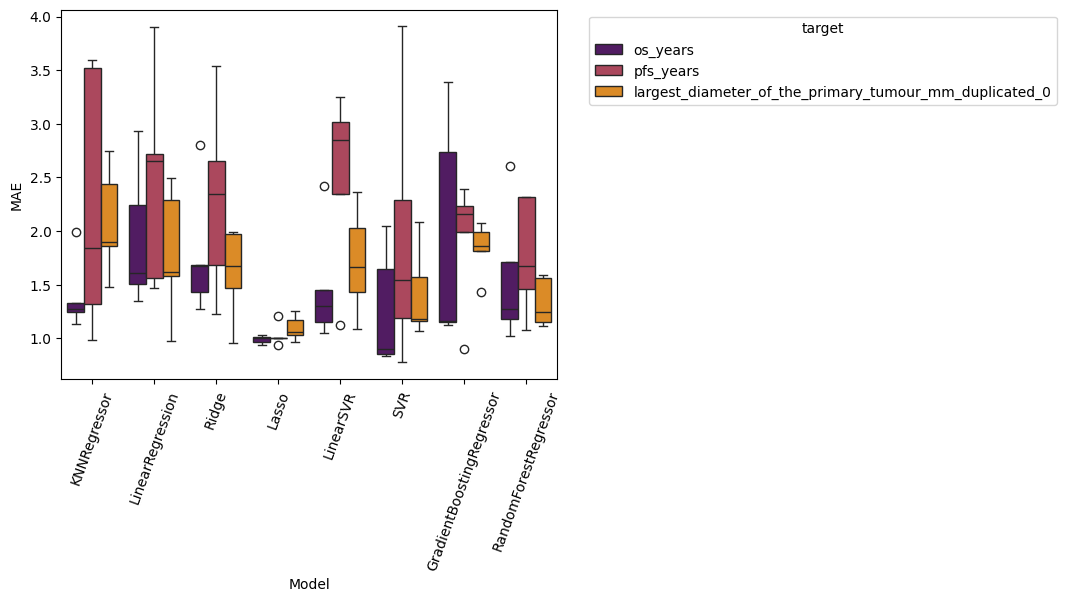

In [54]:
sns.boxplot(result_df, x="Model", y="MAE", hue="target", palette='inferno')
plt.xticks(rotation=70)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='target')

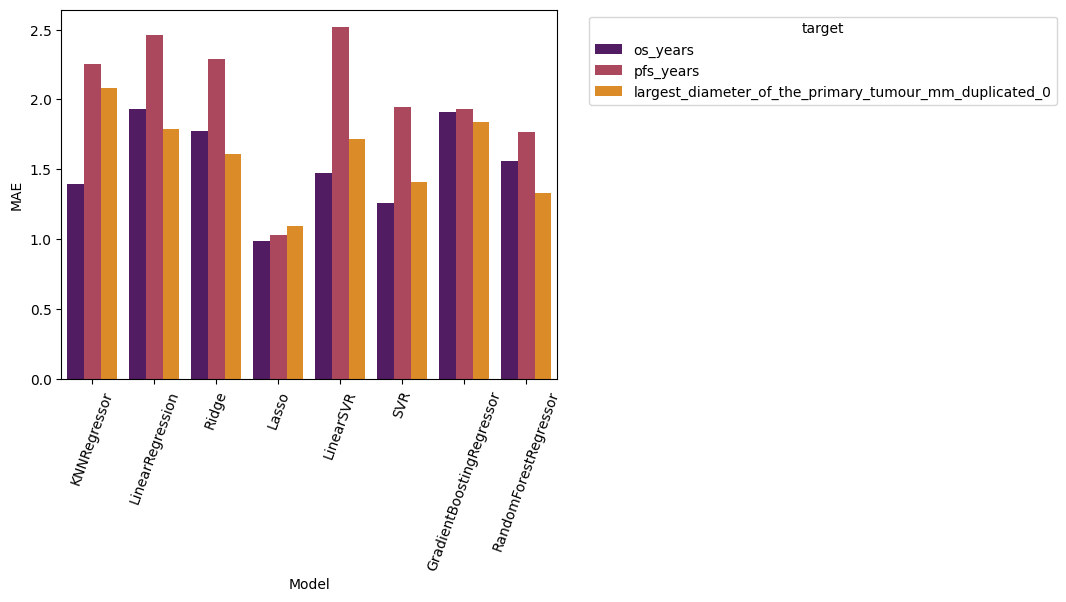

In [55]:
sns.barplot(summary_df, x="Model", y="MAE", hue="target", palette='inferno')
plt.xticks(rotation=70)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='target')

We can see that all three regression task are extremely badly predicted by input features, with mean average percentage errors exceeding 1 in most cases. It is notable that Lasso shows best performance.

### Classification task benchmark

In [85]:
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

model_dict = {
    'KNNClassifier': KNeighborsClassifier(),  # No built-in class_weight support
    'LogisticRegression': LogisticRegression(class_weight='balanced'),
    'RidgeClassifier': RidgeClassifier(class_weight='balanced'),
    'LinearSVC': SVC(kernel='linear', class_weight='balanced'),
    'SVC': SVC(class_weight='balanced'),
    'GradientBoostingClassifier': GradientBoostingClassifier(),  # No built-in class_weight support
    'RandomForestClassifier': RandomForestClassifier(class_weight='balanced'),
}

result_dico_clf = {"Model":[], "AUC":[], "target":[]}
summary_dico_clf = {"Model":[], "AUC":[], "target":[]}
CV = 5
for model_name, model in model_dict.items():
    print(f"Cross-validating {model_name} for recurrent_sample..")
    scores = cross_val_score(model, shuff_dataset[list(X_df.columns)], y=shuff_dataset[list(Y_df.columns)]['recurrent_sample'], 
                             cv=CV, n_jobs=-1, scoring='roc_auc')
    scores = [acc for acc in scores]
    result_dico_clf["Model"] += [model_name] * CV
    result_dico_clf["AUC"] += scores
    result_dico_clf["target"] += ['recurrent_sample'] * CV

    summary_dico_clf["Model"] += [model_name]
    summary_dico_clf["AUC"] += [np.mean(scores)]
    summary_dico_clf["target"] += ['recurrent_sample']
result_df_clf = pd.DataFrame(result_dico_clf)
summary_df_clf = pd.DataFrame(summary_dico_clf)

Cross-validating KNNClassifier for recurrent_sample..
Cross-validating LogisticRegression for recurrent_sample..
Cross-validating RidgeClassifier for recurrent_sample..
Cross-validating LinearSVC for recurrent_sample..
Cross-validating SVC for recurrent_sample..
Cross-validating GradientBoostingClassifier for recurrent_sample..
Cross-validating RandomForestClassifier for recurrent_sample..


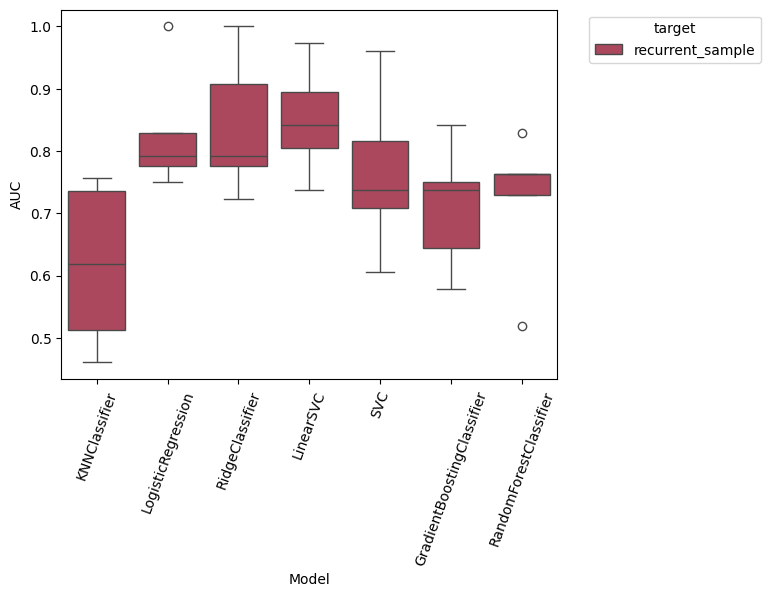

In [86]:
sns.boxplot(result_df_clf, x="Model", y="AUC", hue="target", palette='inferno')
plt.xticks(rotation=70)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='target')

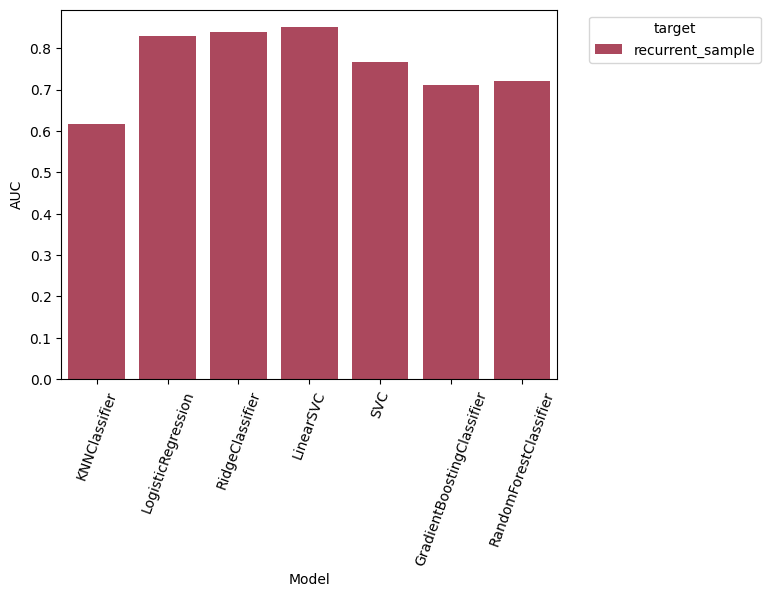

In [87]:
sns.barplot(summary_df_clf, x="Model", y="AUC", hue="target", palette='inferno')
plt.xticks(rotation=70)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='target')

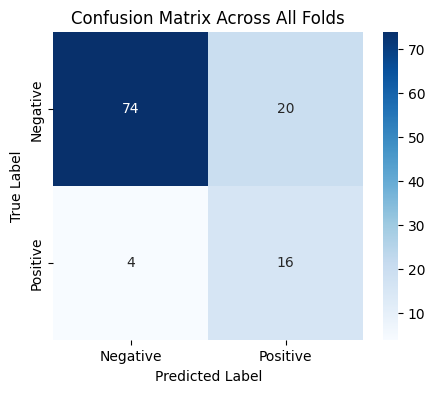

In [89]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=6262)

# Initialize confusion matrix accumulator
avg_conf_matrix = np.zeros((2, 2))

# Store true and predicted labels across all folds
y_true_all = []
y_pred_all = []

# Perform cross-validation
for train_idx, test_idx in cv.split(X_df, Y_df['recurrent_sample']):
    X_train, X_test = X_df.iloc[train_idx,:], X_df.iloc[test_idx,:]
    y_train, y_test = Y_df['recurrent_sample'].iloc[train_idx], Y_df['recurrent_sample'].iloc[test_idx]
    
    # Train Logistic Regression model
    model = SVC(kernel='linear', class_weight='balanced')
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Store predictions and true labels
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Compute the confusion matrix
avg_conf_matrix = confusion_matrix(y_true_all, y_pred_all)

# Plot the average confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(avg_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Across All Folds')
plt.show()

We can see that the task of identifying recurrent samples is already fairly achieved using just the clinical embeddings, however a lot of samples are misclassified as recurrent.

### Conclusion
The above plots and performances demonstrate why clinical information only is not sufficient to pose prognosis on regression target variables. This is why complementing a sample's representation using othe rmodalities such as Genomic, Transcriptomic, Spatial transcriptomic profiles as well as histlogy slides should help improve prognosis. At least this the assumption we choose to make, as other modalities will each bring a new facet of information on a patient's sample. Regarding prediction of reccurency, we hope that the addition of other modalities will help bring even better performances.